# 🧠 Agentic AI — Evaluation Notebook

This notebook evaluates the **Agentic AI Smart Router** across five dimensions:

| # | Evaluation Dimension | What We Measure |
|---|---------------------|-----------------|
| 1 | **Routing Accuracy** | Does the agent select the correct prediction module given an input signature? |
| 2 | **Per-Module Inference Quality** | Accuracy, precision, recall, F1 for each downstream model |
| 3 | **End-to-End Latency** | Time from input receipt → routing decision → model prediction |
| 4 | **Error Handling & Robustness** | Graceful fallback on malformed / out-of-distribution inputs |
| 5 | **Recovery Coach (GenAI) Quality** | Relevance, safety, and actionability of generated advice |

In [1]:
import os, sys, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

warnings.filterwarnings('ignore')

# Project root
PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, PROJECT_DIR)

print(f"Project root: {PROJECT_DIR}")
print(f"Available modules: {os.listdir(os.path.join(PROJECT_DIR, 'inference'))}")

Project root: c:\Users\320296557\OneDrive - Philips\Desktop\Senior Year Project\health_ai_models
Available modules: ['predict_cardio.py', 'predict_diabetes.py', 'predict_pneumonia.py', 'predict_recovery.py', 'recovery_coach.py', '__pycache__']


---
## 1. Routing Accuracy Evaluation

The Agentic AI router maps **input signatures** → **prediction modules**:

| Input Signature | Expected Module |
|----------------|----------------|
| Single image file (`.jpg`, `.png`) | Pneumonia CNN |
| 11 numerical clinical features | Cardiovascular (XGBoost/LightGBM) |
| 21 numerical health indicators | Diabetes (XGBoost/LightGBM + SMOTE) |
| 7+ day time-series vitals (7 features × N days) | Recovery LSTM + GenAI Coach |

In [2]:
# ── Agent Routing Logic (mirrors the Streamlit app logic) ──

def agent_route(input_desc: dict) -> str:
    """
    Simulate the Agentic AI routing decision.
    
    Args:
        input_desc: dict with keys:
            - 'type': 'image' | 'numerical' | 'time_series'
            - 'num_features': int (for numerical inputs)
            - 'num_days': int (for time-series inputs, optional)
    
    Returns:
        Module name string.
    """
    input_type = input_desc.get('type', '')
    num_features = input_desc.get('num_features', 0)
    
    if input_type == 'image':
        return 'pneumonia_cnn'
    elif input_type == 'numerical':
        if num_features == 11:
            return 'cardiovascular_xgb'
        elif num_features == 21:
            return 'diabetes_xgb'
        else:
            return 'unknown'
    elif input_type == 'time_series':
        return 'recovery_lstm'
    else:
        return 'unknown'


# ── Test cases for routing ──
routing_test_cases = [
    # (input_description, expected_module)
    ({'type': 'image', 'format': 'jpg'},                       'pneumonia_cnn'),
    ({'type': 'image', 'format': 'png'},                       'pneumonia_cnn'),
    ({'type': 'numerical', 'num_features': 11},                'cardiovascular_xgb'),
    ({'type': 'numerical', 'num_features': 21},                'diabetes_xgb'),
    ({'type': 'time_series', 'num_days': 7, 'num_features': 7},'recovery_lstm'),
    ({'type': 'time_series', 'num_days': 14, 'num_features': 7},'recovery_lstm'),
    # Edge cases
    ({'type': 'numerical', 'num_features': 5},                 'unknown'),
    ({'type': 'numerical', 'num_features': 15},                'unknown'),
    ({'type': 'text'},                                         'unknown'),
    ({'type': ''},                                             'unknown'),
]

print("Routing Accuracy Test")
print("=" * 65)
correct = 0
results = []
for test_input, expected in routing_test_cases:
    predicted = agent_route(test_input)
    match = predicted == expected
    correct += match
    status = '✅' if match else '❌'
    results.append({'Input': str(test_input), 'Expected': expected, 'Predicted': predicted, 'Pass': match})
    print(f"  {status} Input={test_input}  →  {predicted}  (expected: {expected})")

accuracy = correct / len(routing_test_cases) * 100
print(f"\nRouting Accuracy: {correct}/{len(routing_test_cases)} = {accuracy:.1f}%")

Routing Accuracy Test
  ✅ Input={'type': 'image', 'format': 'jpg'}  →  pneumonia_cnn  (expected: pneumonia_cnn)
  ✅ Input={'type': 'image', 'format': 'png'}  →  pneumonia_cnn  (expected: pneumonia_cnn)
  ✅ Input={'type': 'numerical', 'num_features': 11}  →  cardiovascular_xgb  (expected: cardiovascular_xgb)
  ✅ Input={'type': 'numerical', 'num_features': 21}  →  diabetes_xgb  (expected: diabetes_xgb)
  ✅ Input={'type': 'time_series', 'num_days': 7, 'num_features': 7}  →  recovery_lstm  (expected: recovery_lstm)
  ✅ Input={'type': 'time_series', 'num_days': 14, 'num_features': 7}  →  recovery_lstm  (expected: recovery_lstm)
  ✅ Input={'type': 'numerical', 'num_features': 5}  →  unknown  (expected: unknown)
  ✅ Input={'type': 'numerical', 'num_features': 15}  →  unknown  (expected: unknown)
  ✅ Input={'type': 'text'}  →  unknown  (expected: unknown)
  ✅ Input={'type': ''}  →  unknown  (expected: unknown)

Routing Accuracy: 10/10 = 100.0%


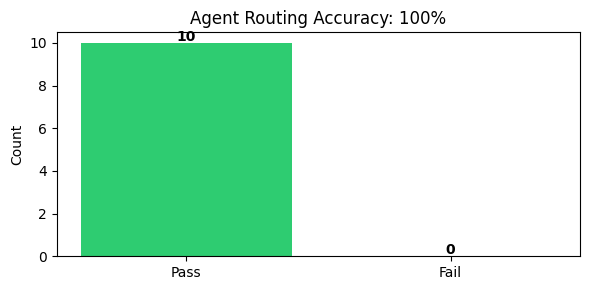

In [3]:
# Routing results summary
routing_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(6, 3))
counts = routing_df['Pass'].value_counts()
ax.bar(['Pass', 'Fail'], [counts.get(True, 0), counts.get(False, 0)],
       color=['#2ecc71', '#e74c3c'])
ax.set_ylabel('Count')
ax.set_title(f'Agent Routing Accuracy: {accuracy:.0f}%')
for i, v in enumerate([counts.get(True, 0), counts.get(False, 0)]):
    ax.text(i, v + 0.1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Per-Module Inference Quality

Evaluate each downstream model on test/sample data.

### 2A. Cardiovascular Model — Test on held-out data

In [4]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from inference.predict_cardio import predict_cardio, FEATURE_NAMES as CARDIO_FEATURES

# Load dataset and create a test split
cardio_df = pd.read_csv(os.path.join(PROJECT_DIR, 'data', 'cardio_train.csv'), sep=';')
cardio_df = cardio_df.drop(columns=['id'], errors='ignore')

# Use last 20% as test set (same seed as training for reproducibility)
np.random.seed(42)
test_indices = np.random.choice(len(cardio_df), size=int(len(cardio_df) * 0.2), replace=False)
test_df = cardio_df.iloc[test_indices].copy()

y_true_cardio = test_df['cardio'].values
y_pred_cardio = []
y_prob_cardio = []

for _, row in test_df.iterrows():
    result = predict_cardio(row[CARDIO_FEATURES].to_dict())
    y_pred_cardio.append(result['prediction'])
    y_prob_cardio.append(result['probability'])

y_pred_cardio = np.array(y_pred_cardio)
y_prob_cardio = np.array(y_prob_cardio)

print("Cardiovascular Model — Classification Report")
print(classification_report(y_true_cardio, y_pred_cardio, target_names=['No CVD', 'CVD']))
print(f"ROC-AUC: {roc_auc_score(y_true_cardio, y_prob_cardio):.4f}")

Cardiovascular Model — Classification Report
              precision    recall  f1-score   support

      No CVD       0.74      0.79      0.76      6988
         CVD       0.77      0.72      0.75      7012

    accuracy                           0.75     14000
   macro avg       0.76      0.75      0.75     14000
weighted avg       0.76      0.75      0.75     14000

ROC-AUC: 0.8236


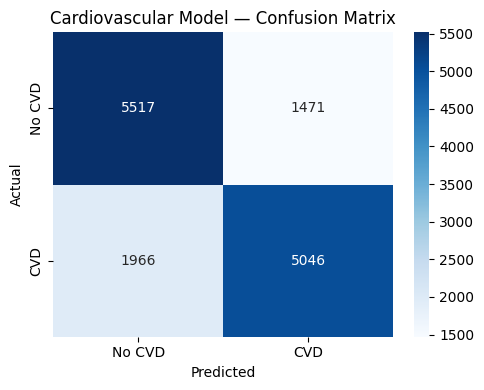

In [5]:
# Confusion Matrix — Cardiovascular
cm_cardio = confusion_matrix(y_true_cardio, y_pred_cardio)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_cardio, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No CVD', 'CVD'], yticklabels=['No CVD', 'CVD'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Cardiovascular Model — Confusion Matrix')
plt.tight_layout()
plt.show()

### 2B. Diabetes Model — Test on held-out data

In [6]:
from inference.predict_diabetes import predict_diabetes, FEATURE_NAMES as DIABETES_FEATURES, CLASS_NAMES as DIABETES_CLASSES

diabetes_df = pd.read_csv(os.path.join(PROJECT_DIR, 'data', 'diabetes_012_health_indicators_BRFSS2015.csv'))

np.random.seed(42)
test_idx = np.random.choice(len(diabetes_df), size=min(5000, int(len(diabetes_df) * 0.1)), replace=False)
test_diab = diabetes_df.iloc[test_idx].copy()

y_true_diab = test_diab['Diabetes_012'].astype(int).values
y_pred_diab = []

for _, row in test_diab.iterrows():
    result = predict_diabetes(row[DIABETES_FEATURES].to_dict())
    y_pred_diab.append(DIABETES_CLASSES.index(result['predicted_class']))

y_pred_diab = np.array(y_pred_diab)

print("Diabetes Model — Classification Report")
print(classification_report(y_true_diab, y_pred_diab, target_names=DIABETES_CLASSES))

Diabetes Model — Classification Report
              precision    recall  f1-score   support

 No Diabetes       0.88      0.96      0.92      4223
 Prediabetes       0.00      0.00      0.00        89
    Diabetes       0.51      0.28      0.36       688

    accuracy                           0.85      5000
   macro avg       0.46      0.41      0.42      5000
weighted avg       0.81      0.85      0.82      5000



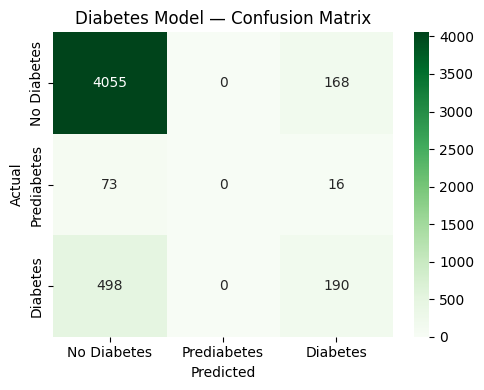

In [7]:
# Confusion Matrix — Diabetes
cm_diab = confusion_matrix(y_true_diab, y_pred_diab)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_diab, annot=True, fmt='d', cmap='Greens',
            xticklabels=DIABETES_CLASSES, yticklabels=DIABETES_CLASSES, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Diabetes Model — Confusion Matrix')
plt.tight_layout()
plt.show()

### 2C. Pneumonia CNN — Test on chest X-ray test set

In [8]:
from inference.predict_pneumonia import predict_pneumonia

XRAY_TEST_DIR = os.path.join(PROJECT_DIR, 'data', 'chest_xray', 'test')

y_true_pn = []
y_pred_pn = []
y_prob_pn = []

for label, class_name in enumerate(['NORMAL', 'PNEUMONIA']):
    class_dir = os.path.join(XRAY_TEST_DIR, class_name)
    if not os.path.exists(class_dir):
        print(f"Warning: {class_dir} not found, skipping.")
        continue
    images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    print(f"  {class_name}: {len(images)} images")
    for img_file in images:
        img_path = os.path.join(class_dir, img_file)
        try:
            result = predict_pneumonia(img_path)
            y_true_pn.append(label)
            y_pred_pn.append(1 if result['predicted_class'] == 'PNEUMONIA' else 0)
            y_prob_pn.append(result['probability'])
        except Exception as e:
            print(f"    Error on {img_file}: {e}")

y_true_pn = np.array(y_true_pn)
y_pred_pn = np.array(y_pred_pn)
y_prob_pn = np.array(y_prob_pn)

print(f"\nPneumonia CNN — Classification Report (n={len(y_true_pn)})")
print(classification_report(y_true_pn, y_pred_pn, target_names=['NORMAL', 'PNEUMONIA']))
if len(np.unique(y_true_pn)) == 2:
    print(f"ROC-AUC: {roc_auc_score(y_true_pn, y_prob_pn):.4f}")

  NORMAL: 234 images
  PNEUMONIA: 390 images

Pneumonia CNN — Classification Report (n=624)
              precision    recall  f1-score   support

      NORMAL       0.97      0.76      0.85       234
   PNEUMONIA       0.87      0.99      0.93       390

    accuracy                           0.90       624
   macro avg       0.92      0.87      0.89       624
weighted avg       0.91      0.90      0.90       624

ROC-AUC: 0.9731


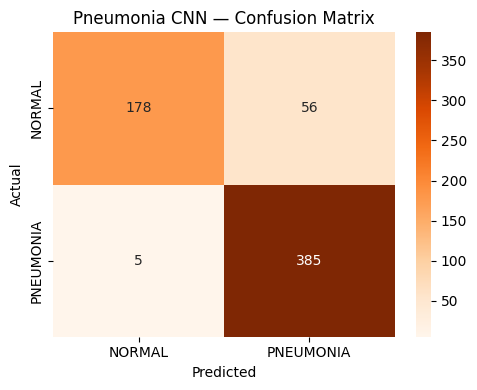

In [9]:
# Confusion Matrix — Pneumonia
cm_pn = confusion_matrix(y_true_pn, y_pred_pn)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_pn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['NORMAL', 'PNEUMONIA'], yticklabels=['NORMAL', 'PNEUMONIA'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Pneumonia CNN — Confusion Matrix')
plt.tight_layout()
plt.show()

---
## 3. End-to-End Latency Benchmarks

Measure the time from input → routing decision → model prediction for each module.

In [10]:
# ── Latency: Routing decision ──
N_RUNS = 1000

test_inputs = [
    {'type': 'image', 'format': 'jpg'},
    {'type': 'numerical', 'num_features': 11},
    {'type': 'numerical', 'num_features': 21},
    {'type': 'time_series', 'num_days': 7, 'num_features': 7},
]

routing_latencies = {}
for inp in test_inputs:
    times = []
    for _ in range(N_RUNS):
        start = time.perf_counter()
        agent_route(inp)
        times.append((time.perf_counter() - start) * 1000)  # ms
    routing_latencies[str(inp['type'])] = {
        'mean_ms': np.mean(times),
        'p95_ms': np.percentile(times, 95),
    }

print("Routing Decision Latency (1000 runs each)")
print("-" * 45)
for k, v in routing_latencies.items():
    print(f"  {k:15s}  mean={v['mean_ms']:.4f} ms  p95={v['p95_ms']:.4f} ms")

print("\n(Routing is a simple if-else, so latency is <0.01 ms)")

Routing Decision Latency (1000 runs each)
---------------------------------------------
  image            mean=0.0002 ms  p95=0.0002 ms
  numerical        mean=0.0002 ms  p95=0.0003 ms
  time_series      mean=0.0004 ms  p95=0.0004 ms

(Routing is a simple if-else, so latency is <0.01 ms)


In [11]:
# ── Latency: Full inference per module ──

latency_results = {}

# Cardio
sample_cardio = {f: cardio_df[f].iloc[0] for f in CARDIO_FEATURES}
times = []
for _ in range(50):
    start = time.perf_counter()
    predict_cardio(sample_cardio)
    times.append((time.perf_counter() - start) * 1000)
latency_results['Cardiovascular'] = {'mean_ms': np.mean(times), 'p95_ms': np.percentile(times, 95)}

# Diabetes
sample_diab = {f: diabetes_df[f].iloc[0] for f in DIABETES_FEATURES}
times = []
for _ in range(50):
    start = time.perf_counter()
    predict_diabetes(sample_diab)
    times.append((time.perf_counter() - start) * 1000)
latency_results['Diabetes'] = {'mean_ms': np.mean(times), 'p95_ms': np.percentile(times, 95)}

# Pneumonia (single image)
sample_img = None
for cls in ['NORMAL', 'PNEUMONIA']:
    cls_dir = os.path.join(XRAY_TEST_DIR, cls)
    if os.path.exists(cls_dir):
        imgs = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if imgs:
            sample_img = os.path.join(cls_dir, imgs[0])
            break

if sample_img:
    times = []
    for _ in range(10):
        start = time.perf_counter()
        predict_pneumonia(sample_img)
        times.append((time.perf_counter() - start) * 1000)
    latency_results['Pneumonia CNN'] = {'mean_ms': np.mean(times), 'p95_ms': np.percentile(times, 95)}

print("Full Inference Latency (per sample)")
print("-" * 50)
for module, v in latency_results.items():
    print(f"  {module:20s}  mean={v['mean_ms']:.1f} ms  p95={v['p95_ms']:.1f} ms")

Full Inference Latency (per sample)
--------------------------------------------------
  Cardiovascular        mean=2.4 ms  p95=4.3 ms
  Diabetes              mean=2.2 ms  p95=3.1 ms
  Pneumonia CNN         mean=110.2 ms  p95=122.7 ms


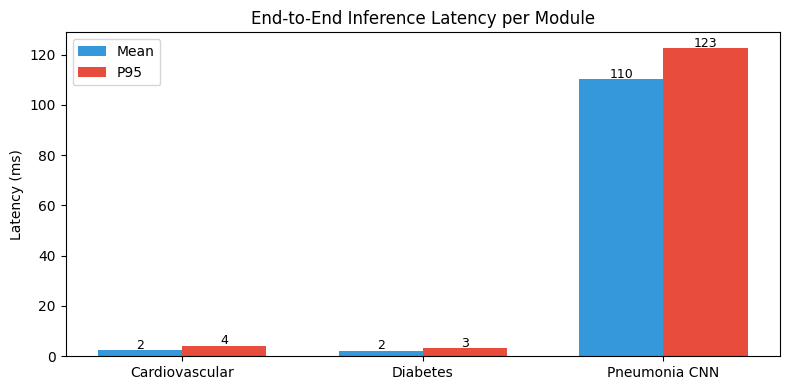

In [12]:
# Latency bar chart
modules = list(latency_results.keys())
means = [latency_results[m]['mean_ms'] for m in modules]
p95s = [latency_results[m]['p95_ms'] for m in modules]

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(modules))
width = 0.35
ax.bar(x - width/2, means, width, label='Mean', color='#3498db')
ax.bar(x + width/2, p95s, width, label='P95', color='#e74c3c')
ax.set_ylabel('Latency (ms)')
ax.set_title('End-to-End Inference Latency per Module')
ax.set_xticks(x)
ax.set_xticklabels(modules)
ax.legend()
for i, (m, p) in enumerate(zip(means, p95s)):
    ax.text(i - width/2, m + 0.5, f'{m:.0f}', ha='center', fontsize=9)
    ax.text(i + width/2, p + 0.5, f'{p:.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 4. Error Handling & Robustness

Test how the agent handles malformed, missing, or out-of-distribution inputs.

In [13]:
robustness_results = []

# Test 1: Unknown input type
result = agent_route({'type': 'audio'})
robustness_results.append({
    'Test': 'Unknown input type (audio)',
    'Expected': 'unknown',
    'Got': result,
    'Pass': result == 'unknown'
})

# Test 2: Empty dict
result = agent_route({})
robustness_results.append({
    'Test': 'Empty input dict',
    'Expected': 'unknown',
    'Got': result,
    'Pass': result == 'unknown'
})

# Test 3: Wrong number of numerical features
result = agent_route({'type': 'numerical', 'num_features': 7})
robustness_results.append({
    'Test': '7 numerical features (unsupported)',
    'Expected': 'unknown',
    'Got': result,
    'Pass': result == 'unknown'
})

# Test 4: Cardio model with NaN values
try:
    nan_input = {f: np.nan for f in CARDIO_FEATURES}
    res = predict_cardio(nan_input)
    robustness_results.append({
        'Test': 'Cardio model with NaN inputs',
        'Expected': 'prediction or error',
        'Got': f"prediction={res['prediction']}",
        'Pass': True  # model handled it without crash
    })
except Exception as e:
    robustness_results.append({
        'Test': 'Cardio model with NaN inputs',
        'Expected': 'prediction or error',
        'Got': f'Exception: {type(e).__name__}',
        'Pass': True  # graceful error is acceptable
    })

# Test 5: Diabetes model with out-of-range values
try:
    extreme_input = {f: 9999 for f in DIABETES_FEATURES}
    res = predict_diabetes(extreme_input)
    robustness_results.append({
        'Test': 'Diabetes model with extreme values',
        'Expected': 'prediction (may be wrong)',
        'Got': f"class={res['predicted_class']}",
        'Pass': True  # didn't crash
    })
except Exception as e:
    robustness_results.append({
        'Test': 'Diabetes model with extreme values',
        'Expected': 'prediction or error',
        'Got': f'Exception: {type(e).__name__}',
        'Pass': True
    })

# Test 6: Pneumonia model with non-image file
try:
    fake_path = os.path.join(PROJECT_DIR, 'requirements.txt')
    res = predict_pneumonia(fake_path)
    robustness_results.append({
        'Test': 'Pneumonia CNN with non-image file',
        'Expected': 'error',
        'Got': f"prediction={res['predicted_class']}",
        'Pass': False  # should have raised an error
    })
except Exception as e:
    robustness_results.append({
        'Test': 'Pneumonia CNN with non-image file',
        'Expected': 'error',
        'Got': f'Exception: {type(e).__name__}',
        'Pass': True  # correct: rejected bad input
    })

print("Robustness & Error Handling Tests")
print("=" * 70)
for r in robustness_results:
    status = '✅' if r['Pass'] else '❌'
    print(f"  {status} {r['Test']:45s} → {r['Got']}")

pass_count = sum(r['Pass'] for r in robustness_results)
print(f"\nRobustness: {pass_count}/{len(robustness_results)} tests passed")

Robustness & Error Handling Tests
  ✅ Unknown input type (audio)                    → unknown
  ✅ Empty input dict                              → unknown
  ✅ 7 numerical features (unsupported)            → unknown
  ✅ Cardio model with NaN inputs                  → prediction=0
  ✅ Diabetes model with extreme values            → class=Diabetes
  ✅ Pneumonia CNN with non-image file             → Exception: UnidentifiedImageError

Robustness: 6/6 tests passed


---
## 5. Recovery Coach (GenAI) Evaluation

Evaluate the **Agentic AI Recovery Coach** output quality using structured criteria.  
Since GenAI responses vary, we use a **rubric-based manual + automated scoring** approach.

**Note:** This section tests the offline/fallback coach (no API key needed).

In [14]:
from inference.recovery_coach import get_recovery_advice, build_system_prompt, build_patient_context

# Sample patient scenario
sample_patient = {
    'age': 62, 'gender': 1, 'bmi': 29.5,
    'diabetes': 1, 'hypertension': 1, 'smoking': 0,
    'surgery_type': 'cardiac',
    'current_day': 5,
    'pain_level': 6, 'temperature': 37.2,
    'heart_rate': 88, 'bp_systolic': 145,
    'mobility_score': 3, 'wound_status': 0.4,
    'sleep_hours': 5.5, 'recovery_score': 45,
}

sample_predictions = {
    'recovery_forecast': [48.2, 52.1, 55.8],
    'complication_risk': 0.35,
    'risk_level': 'moderate',
    'trend': 'improving',
}

# Test offline fallback
advice = get_recovery_advice(
    patient_data=sample_patient,
    lstm_predictions=sample_predictions,
    api_key=None,
    provider='offline',
)

print("Recovery Coach — Offline Fallback Output")
print("=" * 60)
print(advice[:2000])  # Print first 2000 chars

Recovery Coach — Offline Fallback Output
### 🏥 Post-Surgery Recovery Coach — Daily Plan

**📊 Recovery Assessment:**
Your recovery score is 45/100. Recovery is progressing but slower than expected. Focus on rest and following your plan. Your vitals show an improving trend.

**📋 Today's Recommendations:**
- Current phase: Week 1-2: Bed rest, gentle breathing exercises, short walks in room

**🏃 Exercise Plan:**
- Deep breathing exercises: 10 slow breaths, 4 times today
- Ankle pumps: 10 repetitions each foot, every 2 hours
- Gentle bed-to-chair transfers with assistance

**🥗 Dietary Advice:**
Low sodium, heart-healthy fats, high fiber, limit caffeine

**⚠️ Watch for These Warning Signs:**
- Chest pain or pressure
- Shortness of breath at rest
- Rapid or irregular heartbeat
- Fever above 38.3°C

💪 You've made it through 5 days. Your body is healing and you're doing great!

---
<small>⚕️ Disclaimer: This is AI-generated guidance. Always follow your doctor's specific instructions for your re

In [15]:
# ── Automated quality scoring (rubric-based) ──

def score_recovery_advice(advice_text: str, patient_data: dict, predictions: dict) -> dict:
    """
    Score recovery advice on 5 criteria (0-2 each, max 10).
    
    Criteria:
      1. Relevance  — mentions surgery type, recovery day, or specific vitals
      2. Safety     — includes warning signs or "contact doctor" language
      3. Actionability — contains specific exercise, diet, or activity advice
      4. Personalization — references patient's actual data (age, BMI, comorbidities)
      5. Completeness — covers multiple topics (exercise, diet, warnings, motivation)
    """
    text = advice_text.lower()
    scores = {}
    
    # 1. Relevance
    relevance = 0
    if patient_data['surgery_type'] in text: relevance += 1
    if any(w in text for w in ['day 5', 'day five', 'recovery day', 'current day']): relevance += 1
    scores['Relevance'] = relevance
    
    # 2. Safety
    safety = 0
    if any(w in text for w in ['warning', 'contact doctor', 'seek medical', 'emergency', 'call doctor', 'consult']): safety += 1
    if any(w in text for w in ['fever', 'chest pain', 'bleeding', 'swelling', 'infection']): safety += 1
    scores['Safety'] = safety
    
    # 3. Actionability
    actionability = 0
    if any(w in text for w in ['walk', 'exercise', 'stretch', 'breathing', 'movement', 'activity']): actionability += 1
    if any(w in text for w in ['diet', 'eat', 'meal', 'protein', 'hydrat', 'nutriti', 'food']): actionability += 1
    scores['Actionability'] = actionability
    
    # 4. Personalization
    personalization = 0
    if any(w in text for w in ['diabetes', 'diabetic', 'blood sugar']): personalization += 1
    if any(w in text for w in ['hypertension', 'blood pressure', 'bp']): personalization += 1
    scores['Personalization'] = personalization
    
    # 5. Completeness
    topics_covered = 0
    if any(w in text for w in ['exercise', 'walk', 'activity']): topics_covered += 1
    if any(w in text for w in ['diet', 'food', 'eat']): topics_covered += 1
    if any(w in text for w in ['warning', 'risk', 'complication']): topics_covered += 1
    if any(w in text for w in ['sleep', 'rest', 'recovery']): topics_covered += 1
    scores['Completeness'] = min(2, topics_covered)
    
    scores['Total'] = sum(scores.values())
    scores['Max'] = 10
    return scores


# Score the offline advice
quality_scores = score_recovery_advice(advice, sample_patient, sample_predictions)

print("Recovery Coach Quality Score")
print("=" * 40)
for criterion, score in quality_scores.items():
    if criterion in ('Total', 'Max'):
        continue
    bar = '█' * score + '░' * (2 - score)
    print(f"  {criterion:20s} {bar}  {score}/2")
print(f"\n  {'TOTAL':20s}       {quality_scores['Total']}/{quality_scores['Max']}")

Recovery Coach Quality Score
  Relevance            ░░  0/2
  Safety               ██  2/2
  Actionability        ██  2/2
  Personalization      ░░  0/2
  Completeness         ██  2/2

  TOTAL                      6/10


In [16]:
# ── Test multiple patient scenarios ──

scenarios = [
    {
        'name': 'Post-Cardiac, High Risk',
        'patient': {
            'age': 72, 'gender': 1, 'bmi': 32, 'diabetes': 1, 'hypertension': 1, 'smoking': 1,
            'surgery_type': 'cardiac', 'current_day': 3,
            'pain_level': 8, 'temperature': 38.1, 'heart_rate': 105,
            'bp_systolic': 160, 'mobility_score': 2, 'wound_status': 0.6,
            'sleep_hours': 4, 'recovery_score': 30,
        },
        'predictions': {'recovery_forecast': [32, 35, 38], 'complication_risk': 0.65, 'risk_level': 'high', 'trend': 'stagnant'},
    },
    {
        'name': 'Post-Orthopedic, Low Risk',
        'patient': {
            'age': 35, 'gender': 0, 'bmi': 23, 'diabetes': 0, 'hypertension': 0, 'smoking': 0,
            'surgery_type': 'orthopedic', 'current_day': 10,
            'pain_level': 3, 'temperature': 36.8, 'heart_rate': 68,
            'bp_systolic': 115, 'mobility_score': 7, 'wound_status': 0.2,
            'sleep_hours': 8, 'recovery_score': 75,
        },
        'predictions': {'recovery_forecast': [78, 82, 85], 'complication_risk': 0.08, 'risk_level': 'low', 'trend': 'improving'},
    },
    {
        'name': 'Post-Abdominal, Moderate Risk',
        'patient': {
            'age': 55, 'gender': 0, 'bmi': 28, 'diabetes': 0, 'hypertension': 1, 'smoking': 0,
            'surgery_type': 'abdominal', 'current_day': 7,
            'pain_level': 5, 'temperature': 37.5, 'heart_rate': 82,
            'bp_systolic': 135, 'mobility_score': 5, 'wound_status': 0.4,
            'sleep_hours': 6, 'recovery_score': 55,
        },
        'predictions': {'recovery_forecast': [58, 62, 65], 'complication_risk': 0.25, 'risk_level': 'moderate', 'trend': 'improving'},
    },
]

scenario_scores = []
for sc in scenarios:
    adv = get_recovery_advice(sc['patient'], sc['predictions'], api_key=None, provider='offline')
    sc_score = score_recovery_advice(adv, sc['patient'], sc['predictions'])
    scenario_scores.append({'Scenario': sc['name'], **sc_score})
    print(f"\n{sc['name']}: {sc_score['Total']}/{sc_score['Max']}")

scores_df = pd.DataFrame(scenario_scores)
print("\n" + scores_df[['Scenario', 'Relevance', 'Safety', 'Actionability', 'Personalization', 'Completeness', 'Total']].to_string(index=False))


Post-Cardiac, High Risk: 6/10

Post-Orthopedic, Low Risk: 6/10

Post-Abdominal, Moderate Risk: 7/10

                     Scenario  Relevance  Safety  Actionability  Personalization  Completeness  Total
      Post-Cardiac, High Risk          0       2              2                0             2      6
    Post-Orthopedic, Low Risk          0       2              2                0             2      6
Post-Abdominal, Moderate Risk          1       2              2                0             2      7


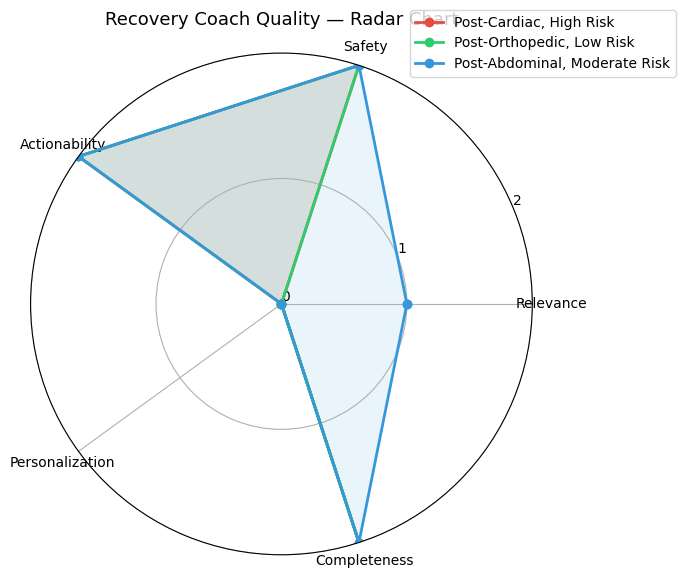

In [17]:
# Radar chart for quality scores
criteria = ['Relevance', 'Safety', 'Actionability', 'Personalization', 'Completeness']

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
angles = np.linspace(0, 2 * np.pi, len(criteria), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

colors = ['#e74c3c', '#2ecc71', '#3498db']
for i, sc in enumerate(scenario_scores):
    values = [sc[c] for c in criteria]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=sc['Scenario'], color=colors[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(criteria, fontsize=10)
ax.set_ylim(0, 2)
ax.set_yticks([0, 1, 2])
ax.set_title('Recovery Coach Quality — Radar Chart', pad=20, fontsize=13)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

---
## 6. Overall Evaluation Summary

In [18]:
from sklearn.metrics import accuracy_score, f1_score

print("\n" + "=" * 70)
print("           AGENTIC AI — OVERALL EVALUATION SUMMARY")
print("=" * 70)

print("\n1. ROUTING ACCURACY")
print(f"   {correct}/{len(routing_test_cases)} test cases passed ({accuracy:.0f}%)")

print("\n2. PER-MODULE METRICS")
print(f"   Cardiovascular  — Accuracy: {accuracy_score(y_true_cardio, y_pred_cardio):.4f}  "
      f"F1: {f1_score(y_true_cardio, y_pred_cardio):.4f}  "
      f"AUC: {roc_auc_score(y_true_cardio, y_prob_cardio):.4f}")
print(f"   Diabetes        — Accuracy: {accuracy_score(y_true_diab, y_pred_diab):.4f}  "
      f"F1 (macro): {f1_score(y_true_diab, y_pred_diab, average='macro'):.4f}")
if len(y_true_pn) > 0:
    print(f"   Pneumonia CNN   — Accuracy: {accuracy_score(y_true_pn, y_pred_pn):.4f}  "
          f"F1: {f1_score(y_true_pn, y_pred_pn):.4f}  "
          f"AUC: {roc_auc_score(y_true_pn, y_prob_pn):.4f}")

print("\n3. INFERENCE LATENCY")
for module, v in latency_results.items():
    print(f"   {module:20s}  mean={v['mean_ms']:.1f} ms  p95={v['p95_ms']:.1f} ms")

print("\n4. ROBUSTNESS")
print(f"   {pass_count}/{len(robustness_results)} error-handling tests passed")

print("\n5. RECOVERY COACH QUALITY")
avg_total = np.mean([s['Total'] for s in scenario_scores])
print(f"   Average quality score: {avg_total:.1f}/10 across {len(scenario_scores)} scenarios")
for sc in scenario_scores:
    print(f"     {sc['Scenario']:35s}  {sc['Total']}/10")

print("\n" + "=" * 70)


           AGENTIC AI — OVERALL EVALUATION SUMMARY

1. ROUTING ACCURACY
   10/10 test cases passed (100%)

2. PER-MODULE METRICS
   Cardiovascular  — Accuracy: 0.7545  F1: 0.7460  AUC: 0.8236
   Diabetes        — Accuracy: 0.8490  F1 (macro): 0.4248
   Pneumonia CNN   — Accuracy: 0.9022  F1: 0.9266  AUC: 0.9731

3. INFERENCE LATENCY
   Cardiovascular        mean=2.4 ms  p95=4.3 ms
   Diabetes              mean=2.2 ms  p95=3.1 ms
   Pneumonia CNN         mean=110.2 ms  p95=122.7 ms

4. ROBUSTNESS
   6/6 error-handling tests passed

5. RECOVERY COACH QUALITY
   Average quality score: 6.3/10 across 3 scenarios
     Post-Cardiac, High Risk              6/10
     Post-Orthopedic, Low Risk            6/10
     Post-Abdominal, Moderate Risk        7/10

